# EDA — Eurocontrol flight delays dataset

Source: `345rf4gt56t4r3e3/flight-delays-europe-2023-2025` on HuggingFace (~15.3M flights, Europe, 2023-2025).

This notebook works on a **streamed sample** (not the full 15.3M rows) — enough to understand the data shape and validate our 7-airport scope before building the real feature pipeline in `pipeline/beam_features.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from datasets import load_dataset

pd.set_option("display.max_columns", None)

\\wsl.localhost\Ubuntu-22.04\home\mikol\LiveAirspaceOpsDashboard\repo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load a sample

Streaming mode reads the dataset row by row without downloading the whole file — we take the first `SAMPLE_SIZE` rows.

In [2]:
SAMPLE_SIZE = 300_000
AIRPORTS = ["EDDF", "EPWA", "EGLL", "LFPG", "EHAM", "EDDM", "EPGD"]

ds = load_dataset("345rf4gt56t4r3e3/flight-delays-europe-2023-2025", split="train", streaming=True)
df = pd.DataFrame(ds.take(SAMPLE_SIZE))
df.shape

(300000, 24)

## 2. What's actually in a row?

Each row is one **flight**, not just a route pair. Columns break down into:

- **flight identity**: `id`, `icao24` (unique aircraft transponder address), `flt_id` (flight number, e.g. `DLH2MM`)
- **timing**: `dof` (date of flight), `first_seen` / `last_seen` (first/last radar timestamp), `unix_time`, `source_month`, `source_year`
- **route**: `adep` / `ades` (departure/arrival ICAO airport), `adep_p` / `ades_p` (parent country/region code), `route` (string, e.g. `EGGP-EGNS`)
- **aircraft**: `registration`, `model`, `typecode`, `icao_aircraft_class`, `icao_operator` (airline)
- **duration**: `duration_min` (actual), `expected_duration_min` (historical median for this route+month)
- **delay label**: `delay_min` (`duration_min - expected_duration_min`), `delayed_15min` (binary target, 1 if `delay_min` ≥ 15)

So: not just a connections graph — it's per-flight records with aircraft + operator + timing detail, which is what lets us build real features later (time of day, day of week, aircraft type, operator).

In [3]:
df.dtypes

id                               uint64
icao24                              str
flt_id                              str
dof                      datetime64[ns]
adep                                str
ades                                str
adep_p                              str
ades_p                              str
registration                        str
model                               str
typecode                            str
icao_aircraft_class                 str
icao_operator                       str
first_seen               datetime64[ns]
last_seen                datetime64[ns]
version                             str
unix_time                       float64
source_month                        str
source_year                       int64
duration_min                    float64
expected_duration_min           float64
delay_min                       float64
delayed_15min                     int64
route                               str
dtype: object

In [4]:
df.head()

,id,icao24,flt_id,dof,adep,ades,adep_p,ades_p,registration,model,typecode,icao_aircraft_class,icao_operator,first_seen,last_seen,version,unix_time,source_month,source_year,duration_min,expected_duration_min,delay_min,delayed_15min,route
0,114227701794411,4011af,MDI04,2023-01-05,EGGP,EGNS,,,G-CEGP,BEECH 200 Super Kingair,BE20,L2T,NaN,2023-01-05 13:02:55,2023-01-05 13:30:15,v2.0.0,1.672924e+09,202301,2023,27.333333,28.250000,-0.916667,0,EGGP-EGNS
1,260918214042583,3c6743,DLH2MM,2023-01-10,EDDM,EDDH,,,D-AIZC,A320 214,A320,L2J,DLH,2023-01-10 06:59:00,2023-01-10 08:06:15,v2.0.0,1.673334e+09,202301,2023,67.250000,65.166667,2.083333,0,EDDM-EDDH
2,310461436086520,406231,CFE88C,2023-01-24,EHAM,EGLC,,,G-LCYL,ERJ 190-100 SR Embraer 190,E190,L2J,CFE,2023-01-24 18:50:05,2023-01-24 19:43:20,v2.0.0,1.674586e+09,202301,2023,53.250000,45.166667,8.083333,0,EHAM-EGLC
3,363325059508470,3c6748,DLH4WF,2023-01-14,EDDM,ENGM,,,D-AIZH,A320 214,A320,L2J,DLH,2023-01-14 08:47:10,2023-01-14 10:46:40,v2.0.0,1.673686e+09,202301,2023,119.500000,117.916667,1.583333,0,EDDM-ENGM
4,375739550072790,471f92,WZZ1BC,2023-01-15,EGGW,LRTR,,,HA-LYW,Airbus 320-232 (W),A320,L2J,WZZ,2023-01-15 21:01:50,2023-01-15 23:27:05,v2.0.0,1.673817e+09,202301,2023,145.250000,143.250000,2.000000,0,EGGW-LRTR


In [5]:
df.isna().mean().sort_values(ascending=False).rename("pct_missing")

icao_operator            0.356917
model                    0.288047
icao_aircraft_class      0.014370
typecode                 0.002693
registration             0.001407
id                       0.000000
flt_id                   0.000000
icao24                   0.000000
ades_p                   0.000000
adep_p                   0.000000
ades                     0.000000
adep                     0.000000
dof                      0.000000
first_seen               0.000000
last_seen                0.000000
version                  0.000000
unix_time                0.000000
source_month             0.000000
source_year              0.000000
duration_min             0.000000
expected_duration_min    0.000000
delay_min                0.000000
delayed_15min            0.000000
route                    0.000000
Name: pct_missing, dtype: float64

## 3. Time range covered by this sample

date range: 2023-01-02 00:00:00 -> 2023-02-28 00:00:00


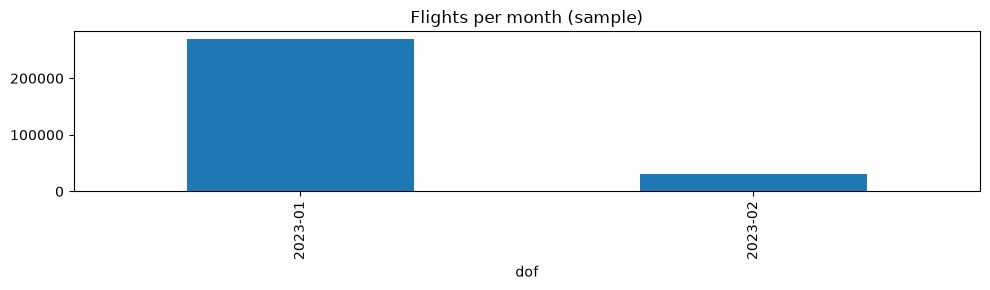

In [6]:
df["dof"] = pd.to_datetime(df["dof"])
print("date range:", df["dof"].min(), "->", df["dof"].max())

monthly = df["dof"].dt.to_period("M").astype(str).value_counts().sort_index()
monthly.plot(kind="bar", figsize=(10, 3), title="Flights per month (sample)")
plt.tight_layout()
plt.show()

Note: streaming reads the file in its stored order, and this dataset appears sorted by date — so the first 300k rows only cover ~2 months, not a random spread across 2023-2025. Fine for structural EDA, but the real feature pipeline (Phase 1) must process the **full** file rather than an early slice, or explicitly sample across the whole date range.

## 4. Filter down to our 7 airports

A flight "touches" our scope if either the departure or the arrival airport is in `AIRPORTS`.

matched: 88758 / 300000 (29.6%)


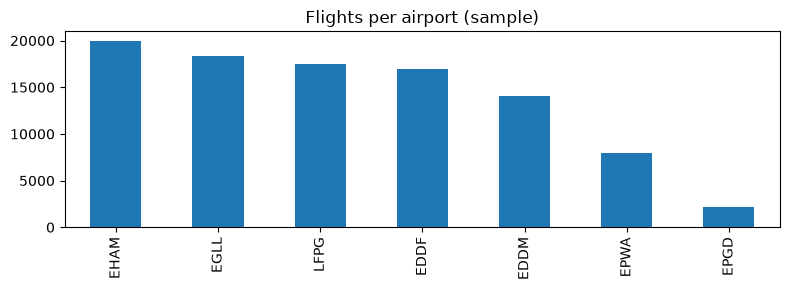

EHAM    19993
EGLL    18297
LFPG    17532
EDDF    16966
EDDM    14074
EPWA     7998
EPGD     2203
dtype: int64

In [7]:
mask = df["adep"].isin(AIRPORTS) | df["ades"].isin(AIRPORTS)
matched = df[mask].copy()

print(f"matched: {len(matched)} / {len(df)} ({len(matched) / len(df):.1%})")

counts = pd.Series({code: ((df["adep"] == code) | (df["ades"] == code)).sum() for code in AIRPORTS}).sort_values(ascending=False)
counts.plot(kind="bar", figsize=(8, 3), title="Flights per airport (sample)")
plt.tight_layout()
plt.show()
counts

## 5. Delay label balance

This is the target we'll train on later. It's imbalanced, which matters for choosing metrics (AUC/F1 over raw accuracy) and possibly class weighting in Phase 2.

delayed_15min
0    0.936524
1    0.063476
Name: proportion, dtype: float64


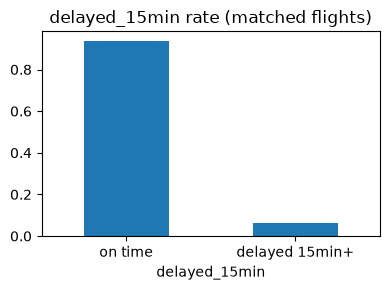

In [8]:
rate = matched["delayed_15min"].value_counts(normalize=True)
print(rate)
rate.plot(kind="bar", figsize=(4, 3), title="delayed_15min rate (matched flights)")
plt.xticks([0, 1], ["on time", "delayed 15min+"], rotation=0)
plt.tight_layout()
plt.show()

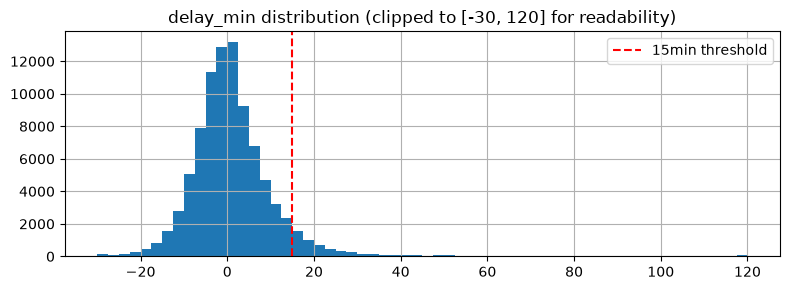

In [9]:
matched["delay_min"].clip(-30, 120).hist(bins=60, figsize=(8, 3))
plt.axvline(15, color="red", linestyle="--", label="15min threshold")
plt.title("delay_min distribution (clipped to [-30, 120] for readability)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Route network

Two views: (a) the internal network — routes where *both* ends are one of our 7 airports, and (b) the busiest external connections — everywhere else our airports fly to/from.

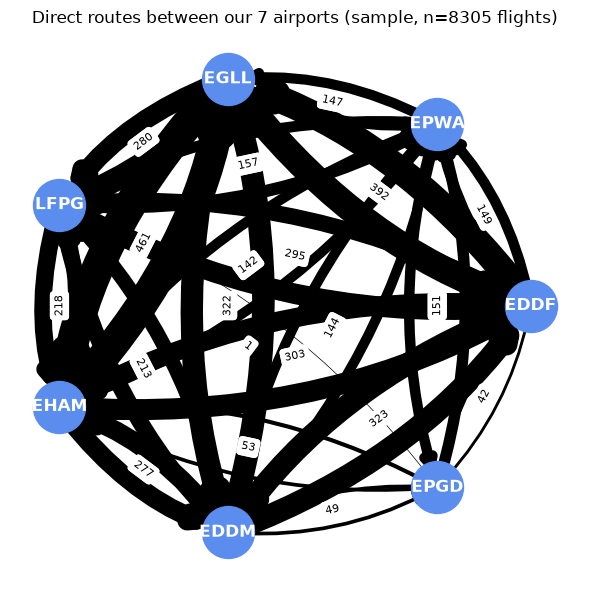

In [10]:
internal = matched[matched["adep"].isin(AIRPORTS) & matched["ades"].isin(AIRPORTS)]
edge_weights = Counter(zip(internal["adep"], internal["ades"]))

G = nx.DiGraph()
G.add_nodes_from(AIRPORTS)
for (a, b), w in edge_weights.items():
    G.add_edge(a, b, weight=w)

pos = nx.circular_layout(G)
weights = [G[u][v]["weight"] for u, v in G.edges()]

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, pos, node_color="#5B8DEF", node_size=1400)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, width=[max(0.5, w / 20) for w in weights], connectionstyle="arc3,rad=0.15", arrowsize=15)
nx.draw_networkx_edge_labels(G, pos, edge_labels={k: v for k, v in edge_weights.items()}, font_size=8)
plt.title(f"Direct routes between our 7 airports (sample, n={len(internal)} flights)")
plt.axis("off")
plt.tight_layout()
plt.show()

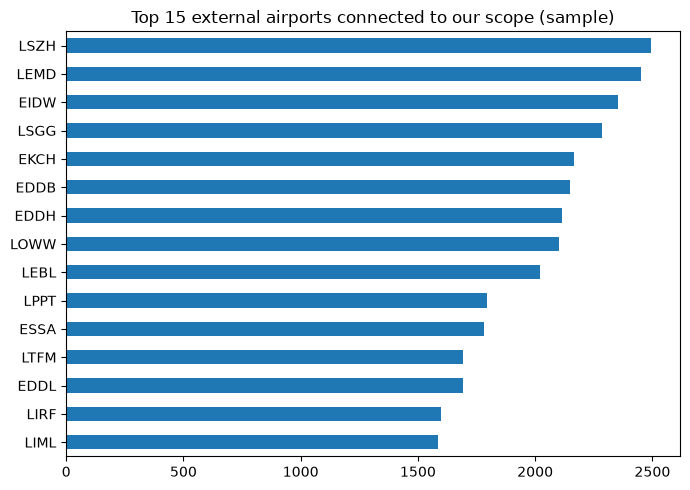

In [11]:
external = matched[~(matched["adep"].isin(AIRPORTS) & matched["ades"].isin(AIRPORTS))]
other_end = external.apply(lambda r: r["ades"] if r["adep"] in AIRPORTS else r["adep"], axis=1)

other_end.value_counts().head(15).sort_values().plot(kind="barh", figsize=(7, 5), title="Top 15 external airports connected to our scope (sample)")
plt.tight_layout()
plt.show()

## 7. Aircraft & operators

Bonus context the label alone doesn't show — which aircraft types and airlines dominate our scope.

In [12]:
matched["typecode"].value_counts().head(10)

typecode
A320    19268
A319    10284
A20N     8759
E190     7724
B738     7318
A321     5231
CRJ9     3695
A21N     3409
E195     3365
BCS3     2945
Name: count, dtype: int64

In [13]:
matched["icao_operator"].value_counts().head(10)

icao_operator
DLH    17281
BAW    10046
AFR     6387
KLC     5365
KLM     4856
LOT     3280
EZY     1952
HOP     1615
DLA     1262
WZZ     1198
Name: count, dtype: int64

## Summary

- Dataset is per-flight, not just a route list: aircraft identity, operator, timing, and a ready-made delay label are all present.
- ~30% of sampled flights touch one of our 7 airports — scaled to the full 15.3M rows that's a few million flights, plenty for training.
- EPGD (Gdańsk) has roughly 8x less traffic than the busiest hub (EHAM) — expect noisier predictions there, worth calling out on the demo.
- `delayed_15min` is imbalanced (~7% positive) — plan for AUC/F1 over accuracy, possibly class weights, in Phase 2.

**Next step (Phase 1):** build `pipeline/beam_features.py` — stream the *full* dataset, filter to our airports, and aggregate into training features (rolling delay rate, traffic density per airport per hour, etc.), joined with Open-Meteo weather.